In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/GGTC/chainB_pS136/'

In [2]:
# dataframe
df = pd.DataFrame()
residues = np.arange(15,183)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][:168]
    rmsf.append(dat)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_chainA.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,15,1.797667,0.193811
1,16,1.501333,0.181526
2,17,1.545000,0.188183
3,18,1.373000,0.178606
4,19,1.186667,0.161290
5,20,1.098333,0.143611
6,21,1.052333,0.133819
7,22,1.093667,0.123011
8,23,1.171333,0.144691
9,24,1.330667,0.154378


In [3]:
# dataframe
df = pd.DataFrame()
residues = np.arange(15,183)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][168:]
    rmsf.append(dat)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_chainB.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,15,3.445000,0.603024
1,16,2.361667,0.435258
2,17,1.715667,0.109935
3,18,1.568333,0.077347
4,19,1.419667,0.043895
5,20,1.369667,0.069323
6,21,1.412667,0.124255
7,22,1.518333,0.136792
8,23,1.610000,0.152631
9,24,1.754667,0.173731


In [4]:
# dataframe
df = pd.DataFrame()
residues = np.arange(15,183)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][:168]
    dat2 = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][168:]
    
    rmsf.append(dat)
    rmsf.append(dat2)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims*2)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_avgchain.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,15,2.621333,0.461921
1,16,1.931500,0.294008
2,17,1.630333,0.114404
3,18,1.470667,0.105169
4,19,1.303167,0.096163
5,20,1.234000,0.097082
6,21,1.232500,0.117247
7,22,1.306000,0.126393
8,23,1.390667,0.138115
9,24,1.542667,0.144894


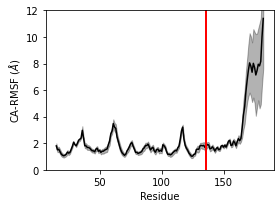

In [4]:
df = pd.read_csv('RMSF_data_chainA.csv')

ymax = 12

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(136,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainA.pdf')



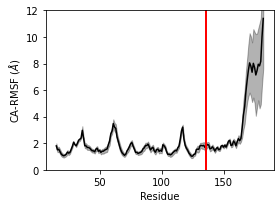

In [5]:
df = pd.read_csv('RMSF_data_chainA.csv')

ymax = 12

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(136,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainA.png')




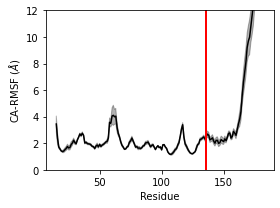

In [6]:
df = pd.read_csv('RMSF_data_chainB.csv')

ymax = 12

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(136,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainB.pdf')




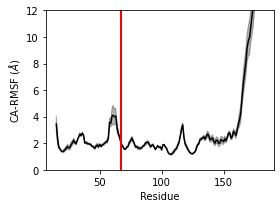

In [7]:
df = pd.read_csv('RMSF_data_chainB.csv')

ymax = 12

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(67,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainB.png')



